# **Preprocesamiento de imágenes**

Update - 21-11-23

A petición del profesor, se modificó el código para que este pudiese correr en cualquier maquina sin tenerle que hacer modificaciones.
Se le indica al lector que para ejecutar este notebook no es necesario que cree todas las rutas de las imágenes, unicamente debe asegurarse que este trabajando con todos los archivos del repositorio de GitHub.

Esta es la estructura que debe encontrarse en el repositorio:

```
datos_monografia/
├─ README.md
├─ src/
│  ├─ Procesamiento_de_imagenes.ipynb
│  ├─ Analisis_de_datos.ipynb
├─ data/
│  ├─ structured_data/
│     ├─ app_data.xlsx
```

A continuación se muestra la estructura del proyecto una vez se haya corrido este notebook, pues este mismo descargará las imágenes y las ubicará en carpetas a medida que las vaya filtrando y transformando. 

```
datos_monografia/
├─ README.md
├─ src/
│  ├─ Procesamiento_de_imagenes.ipynb
│  ├─ Analisis_de_datos.ipynb
├─ data/
│  ├─ structured_data/
│     ├─ app_data.xlsx
│  ├─ us_images/
│     ├─ originales/
│     ├─ procesadas/
│        ├─ ordenadas/
│           ├─ con_info/
│           ├─ no_apendice/
│           ├─ no_paciente/
│        ├─ selection/
│           ├─ con_info/
│           ├─ no_apendice/
│           ├─ no_paciente/
```


El presente notebook tiene como objetivo el preprocesar las imágenes de ultrasonido antes de incorporarlas en el entrenamiento y evaluación de la inteligencia artificial.

## Resumen

Como ya se comentó en el archivo README.md, las imágenes de ultrasonido son en su totalidad capturas de pantallas del software donde se visualizan. Generalmente estas capturas de pantalla las generan los radiólogos para poder hacer apuntes o marcas que ayuden al diagnóstico por parte del médico. Si bien se podría hacer un uso completo de todas las imágenes, la información del software que se cuela en la captura de pantalla podría ser irrelevante en el entrenamiento y de momento no se tiene claro que tanto lo podría alterar, por lo cuál a través de OpenCV (cv2) se detectaron los bordes de la imagen para generar el recorte. 

Este procesamiento consta de **4** códigos
- **select_1.py**: Se encarga de tomar todas las imágenes de las que se dispone, hacer un primer filtrado a una carpeta 'selection' con 3 subcarpetas:
    ```
    selection
        con_info: Guarda las imágenes que si tienen diagnóstico
        no_apendice: Guarda las imágenes donde no es posible ver el apéndice
        no_paciente: No se poseen los datos necesarios para clasificar estas imágenes
    ```
    
- **crop_2.py**: Toma las imágenes de la subcarpetas 'con_info' y 'no_apendice', las recorta con identificación de bordes y los resultados los envía a las siguientes carpeta y subcarpetas:
    ```
    recortes 
        con_info: Guarda las imágenes recortadas que si tienen diágnóstico

    ordenadas
        no_apendice: Guarda directamente las imágenes recortadas que sabemos que no muestra el apendice.
    ```

- **select_3.py**: Toma todas las imágenes de la carpeta 'recortes' y las organiza en la carpeta 'ordenadas'
    ```
    ordenadas
        apendicitis: Guarda las imágenes recortadas donde se ve el apéndice y el diagnóstico fue apendicitis
        no_apendicitis: Guarda las imágenes recortadas donde se ve el apéndice y el diagnóstico fue NO apendicitis
        no_apendice: Guarda directamente las imágenes recortadas que sabemos que no muestra el apendice.
    ```

- **ia_data_4.py**: análisis de los resultados de las imágenes.
- **ia_data_5.py**: balanceo de las imágenes, normalización, reshape, vectorización y disposición de la info lista para utilizar en la ia.


Es importante resaltar que todos estos códigos tuvieron que correrse localmente, pues su uso en colab suele ser más lento, dificultando el proceso de desarrollo. En la actualización del 21-11-23 ya no necesario crear carpetas pues el  notebook lo hace automáticamente. 


# Metodología

### Instalar librerías

Las librerías zipfile, os, shutil, pathlib, re, y traceback son parte de la biblioteca estándar de Python y no necesitan instalación adicional. Las librerías requests, pandas, opencv-python (para cv2), tensorflow, numpy, y matplotlib deben ser instaladas para poder ejecutar el notebook

In [22]:
%pip install requests pandas opencv-python matplotlib tensorflow numpy

Note: you may need to restart the kernel to use updated packages.


### Descargar imágenes

Para facilidad del lector, el siguiente código descarga desde el repositorio original el archivo .zip de las imágenes, las descomprime y las almacena en la carpeta esperada.  

In [23]:
import requests
import zipfile
import os
import shutil
from pathlib import Path

# URL del archivo .zip
url = 'https://zenodo.org/records/7711412/files/US_Pictures.zip?download=1'

# Definir la ruta base del proyecto (subiendo dos niveles desde la ubicación actual del script)
base_path = Path.cwd().parent

# Ruta donde quieres guardar el archivo zip
images_path = base_path / 'data' / 'us_images' / 'originales'
zip_path = images_path / 'US_Pictures.zip'

# Ruta donde quieres descomprimir los archivos
extract_path = base_path / 'data' / 'us_images' / 'originales'

# Crear las carpetas de salida si no existen
images_path.mkdir(parents=True, exist_ok=True)
extract_path.mkdir(parents=True, exist_ok=True)

# Descargando el archivo
response = requests.get(url)
with open(zip_path, 'wb') as file:
    file.write(response.content)

# Descomprimiendo el archivo
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for member in zip_ref.namelist():
        filename = os.path.basename(member)
        # Ignora las carpetas dentro del archivo zip
        if not filename:
            continue

        source = zip_ref.open(member)
        target = open(os.path.join(extract_path, filename), "wb")
        with source, target:
            shutil.copyfileobj(source, target)

# Eliminar el archivo zip
os.remove(zip_path)

print('Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código')

Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código


## Primer filtrado

Son 2097 imágenes, pero se deben clasificar haciendo uso de los datos estructurados. 

### Carpetas:

Se encarga de tomar todas las imágenes de las que se dispone, hacer un primer filtrado a una carpeta 'selection' con 3 subcarpetas:

```
    selection
        con_info: Guarda las imágenes que si tienen diagnóstico
        no_apendice: Guarda las imágenes donde no es posible ver el apéndice
        no_paciente: No se poseen los datos necesarios para clasificar estas imágenes
```   
    

In [24]:
# select_1.py

'''
Con este código se pretenden seleccionar las imágenes que cuenten
con información suficiente para poder entrenar el modelo

El resultado de este código entrará al código 'crop.py'
para recortar cada una de las imágenes. 
'''

# Importar las librerías necesarias
import pandas as pd
import os
import re
import traceback
import shutil
from pathlib import Path

# Definir la ruta base del proyecto (subiendo dos niveles desde la ubicación actual del script)
base_path = Path.cwd().parent

# Ruta del archivo de la base de datos estructurada (usando rutas relativas)
file_path = base_path / 'data' / 'structured_data' / 'app_data.xlsx'

# Cargar la primera hoja del archivo Excel en un DataFrame
df = pd.read_excel(file_path, sheet_name=0)

# Columnas seleccionadas
seleccion = ['Appendix_on_US', 'US_Number', 'Diagnosis']

# Especificar las filas (todas) y columnas (seleccion) que se copiaran
df_filtered = df.loc[:, seleccion]

# Función para extraer el número del nombre del archivo con ayuda de las funciones regulares
def extract_number(filename):
    match = re.match(r"(\d+)", filename)
    return int(match.group(1)) if match else None

# Definir las rutas de las carpetas de imágenes (usando rutas relativas)
folder_path = base_path / 'data' / 'us_images' / 'originales' # Originales
con_info = base_path / 'data' / 'us_images' / 'procesadas' / 'selection' / 'con_info' # Imágenes usables
no_apendice = base_path / 'data' / 'us_images' / 'procesadas' / 'selection' / 'no_apendice' # Imágenes sin apéndice
no_paciente = base_path / 'data' / 'us_images' / 'procesadas' / 'selection' / 'no_paciente' # Imágenes no usables

# Crear las carpetas de salida si no existen
con_info.mkdir(parents=True, exist_ok=True)
no_apendice.mkdir(parents=True, exist_ok=True)
no_paciente.mkdir(parents=True, exist_ok=True)


# Procesar cada archivo de imagen en la carpeta de entrada
for filename in os.listdir(folder_path):
    # Revisión que el archivo si corresponda a una imagen
    if filename.lower().endswith(('.png', '.bmp', '.jpeg', '.jpg', '.tif')):
        number = extract_number(filename) # número entero del archivo

        # Se busca en la base de datos filtrada si el número existe y se guardan
        # todos los valores de su fila
        fila_correspondiente = df_filtered.loc[df_filtered['US_Number'] == number]

        try:
            # Verifica que el número y la lista si existan
            if number is not None and fila_correspondiente.empty != True:

                # Revisa si el apendice aparece en la imagen
                if fila_correspondiente['Appendix_on_US'].iloc[0] == 'yes':

                    # Revisa si el diagnóstico es appendicitis o sin esta
                    if fila_correspondiente['Diagnosis'].iloc[0] == 'appendicitis' or\
                    fila_correspondiente['Diagnosis'].iloc[0] == 'no appendicitis':
                        target_folder = con_info

                    # Imágenes que no sirven en el entrenamiento
                    else:
                        target_folder = no_paciente
                
                # Imágenes donde no se ve el apéndice
                else: 
                    target_folder = no_apendice

            # Imágenes cuyos pacientes NO existen en la base de datos
            else:
                target_folder = no_paciente

            # Solo cambia las líneas donde se usan las rutas, por ejemplo:
            shutil.move(folder_path / filename, target_folder / filename)

        except Exception as e:
            # Si hay un error, imprimirlo y continuar con la siguiente imagen
            print(f"No se pudo procesar el archivo: {filename}: {e}")
            traceback.print_exc() # Imprime el tipo de error

print('Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código')

Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código


## Recorte

Aquí se hace uso de la identificación de bordes y se especifica que se descarten aquellos bordes menores a 250 pixeles y cuyo lado más  largo sea mayor a 1.5 veces el lado más corto. Esto evita que se recorten pequeños cuadros que hay en las capturas de pantalla.

### Carpetas:
Toma las imágenes de la subcarpetas 'con_info' y 'no_apendice', las recorta con identificación de bordes y los resultados los envía a las siguientes carpeta y subcarpetas:
    
```
    recortes 
        Guarda las imágenes recortadas que si tienen diágnóstico

    ordenadas
        no_apendice: Guarda directamente las imágenes recortadas que sabemos que no muestra el apendice.
 ```


In [25]:
# crop.py

import cv2
import os
from pathlib import Path

# Definir la ruta base del proyecto
base_path = Path.cwd().parent

# Funciones de ajuste de niveles y recorte de imagen
def ajustar_niveles(imagen, nivel_min, nivel_max):
    """
    Ajusta los niveles de la imagen utilizando cv2.normalize.
    """
    return cv2.normalize(imagen, None, alpha=nivel_min, beta=nivel_max, norm_type=cv2.NORM_MINMAX)

def encontrar_y_recortar_imagen(input_path, output_path):
    """
    Encuentra la imagen de ultrasonido dentro de una captura de pantalla y la recorta
    sin modificar el brillo y el contraste en la imagen recortada.
    """
    # Leer la imagen original
    imagen_original = cv2.imread(input_path, cv2.IMREAD_UNCHANGED)
    
    # Convertir la imagen a escala de grises
    imagen_gris = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)
    
    # Ajustar los niveles de la imagen para mejorar el contraste
    imagen_contrastada = ajustar_niveles(imagen_gris, 0, 255)
    
    # Umbralizar la imagen para obtener una binarización
    _, imagen_binaria = cv2.threshold(imagen_contrastada, 1, 255, cv2.THRESH_BINARY)
    
    # Encontrar los contornos en la imagen binaria
    contornos, _ = cv2.findContours(imagen_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Procesar cada contorno encontrado
    for contorno in contornos:
        # Calcular el rectángulo delimitador para el contorno
        x, y, ancho, alto = cv2.boundingRect(contorno)
        borde_mas_corto = min(ancho, alto)
        borde_mas_largo = max(ancho, alto)
        proporcion = borde_mas_largo / borde_mas_corto

        # Comprobar si el contorno cumple con las condiciones de tamaño mínimo y proporción
        if borde_mas_corto >= 250 and proporcion <= 1.5:
            # Recortar la imagen original (sin ajustes de contraste) según el contorno que cumple con los requisitos
            imagen_recortada = imagen_original[y:y+alto, x:x+ancho]
            
            # Guardar la imagen recortada
            cv2.imwrite(output_path, imagen_recortada)
            break  # Terminar después de procesar el primer contorno válido

# Rutas de las carpetas de imágenes usando rutas relativas
input_folder1 = base_path / 'data' / 'us_images' / 'procesadas' / 'selection' / 'con_info'
output_folder1 = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'con_info'
input_folder2 = base_path / 'data' / 'us_images' / 'procesadas' / 'selection' / 'no_apendice'
output_folder2 = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'no_apendice'

# Crear las carpetas de salida si no existen
output_folder1.mkdir(parents=True, exist_ok=True)
output_folder2.mkdir(parents=True, exist_ok=True)

# Función para procesar las imágenes
def ubicar(input_folder, output_folder):
    for filename in os.listdir(input_folder):
        try:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                input_path = input_folder / filename
                base_name = filename.rsplit('.', 1)[0] + '.png'  # Cambiar la extensión a .png
                output_path = output_folder / base_name
                
                try:
                    encontrar_y_recortar_imagen(str(input_path), str(output_path))
                except Exception as e:
                    print(f"No se pudo procesar el archivo {filename}: {e}")
        except Exception as e:
            print(f"No se pudo procesar el archivo {filename}: {e}")

# Procesar imágenes
ubicar(input_folder1, output_folder1)
ubicar(input_folder2, output_folder2)

print('''
Si hay un archivo que no se puede procesar, es normal, en las pruebas
siempre falla una imagen (803.1) de las 2097 del dataset, es por ello que 
podemos decir que:
      
Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código
''')

No se pudo procesar el archivo 803.1 RLQ lymphadenitis mesenterialis_KLÄREN MIT ALYSSIA.bmp: OpenCV(4.8.1) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:182: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


Si hay un archivo que no se puede procesar, es normal, en las pruebas
siempre falla una imagen (803.1) de las 2097 del dataset, es por ello que 
podemos decir que:
      
Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código



## Ordenar
Hasta el momento solo se tienen ordenadas las imágenes donde el apendice no es visible, pero esto se resuelve con los siguientes códigos.

### Carpetas
Toma todas las imágenes de la carpeta 'recortes' y las organiza en la carpeta 'ordenadas'

```
    ordenadas
        apendicitis: Guarda las imágenes recortadas donde se ve el apéndice y el diagnóstico fue apendicitis
        no_apendicitis: Guarda las imágenes recortadas donde se ve el apéndice y el diagnóstico fue NO apendicitis
        no_apendice: Guarda directamente las imágenes recortadas que sabemos que no muestra el apendice.
```

In [26]:
# select_3.py

import os
import re
import shutil
import traceback
import pandas as pd
from pathlib import Path

# Definir la ruta base del proyecto
base_path = Path.cwd().parent

# Ruta del archivo Excel de la base de datos
file_path = base_path / 'data' / 'structured_data' / 'app_data.xlsx'

# Cargar la primera hoja del archivo Excel en un DataFrame
df = pd.read_excel(file_path, sheet_name=0)

# Columnas seleccionadas
seleccion = ['Appendix_on_US', 'US_Number', 'Diagnosis']

# Filtrar las filas y columnas deseadas
df_filtered = df.loc[:, seleccion]

# Rutas de las carpetas de imágenes y clasificación usando rutas relativas
folder_path = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'con_info'
apendicitis = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'apendicitis'
no_apendicitis = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'no_apendicitis'
no_apendice = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'no_apendice'


# Crear las carpetas de clasificación si no existen
apendicitis.mkdir(parents=True, exist_ok=True)
no_apendicitis.mkdir(parents=True, exist_ok=True)
no_apendice.mkdir(parents=True, exist_ok=True)


# Función para extraer el número del nombre del archivo
def extract_number(filename):
    match = re.match(r"(\d+)", filename)
    return int(match.group(1)) if match else None

# Procesar cada archivo en la carpeta
for filename in os.listdir(folder_path):
    if filename.lower().endswith(('.png', '.bmp', '.jpeg', '.jpg', '.tif')):
        number = extract_number(filename)

        if number is not None:
            fila_correspondiente = df_filtered.loc[df_filtered['US_Number'] == number]

            if not fila_correspondiente.empty:
                diagnosis = fila_correspondiente['Diagnosis'].iloc[0]
                if diagnosis == 'no appendicitis':
                    target_folder = no_apendicitis
                elif diagnosis == 'appendicitis':
                    target_folder = apendicitis

            try:
                shutil.move(str(folder_path / filename), str(target_folder / filename))
            except Exception as e:
                print(f"No se pudo procesar el archivo: {filename}: {e}")
                traceback.print_exc()

print('Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código')

Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código


Finalizando esta etapa, se procedió a revisar los resultados y limpiar manualmente un par de imágenes que parecían no ser importantes. 

## Procesamiento

De aquí en adelante lo que procura es generar una base de datos con las imágenes la cual pueda ser usada para el entrenamiento del modelo a desarrollar.

Este preprocesamiento de imágenes debe ir orientado al modelo que se piensa desarrollar y para ello es importante recordar que la propuesta de este trabajo es el uso de redes neuronales convolucionales, pero cuando se crea una red neuronal nueva todos sus parámetros inician de manera totalmente aleatoria y mediante el entrenamiento se ajustan gradualmente, el problema radica en que en este caso se cuenta únicamente con cientos de datos lo que dificulta este proceso y aumenta el riesgo de caer en sobreajuste.

Por lo anterior se buscará hacer un proceso de "transferencia de aprendizaje" es decir, tomar un modelo que sea bueno reconociendo imágenes de cualquier tipo y entrenarlo sobre este set. Se pretende usar [MobileNetV2](https://tfhub.dev/google/imagenet/mobilenet_v2_130_224/feature_vector/5) donde se descartarían todas las salidas existentes del modelo (1001 clasificaciones), es decir, la útima capa, para remplazarla por otra con 3 clasificaciones ('sin apendice', 'apendicitis', 'no_apendicitis') y se entrenarían solo las últimas capas del modelo (sin tocar las otras), posteriormente se podrían entrenar todas las capas, pero con una tasa de aprendizaje muy baja. Esta entrega no pretende profundizar más sobre esa metodología, pero se deseaba que el lector comprendiese el camino a tomar en futuras entregas.

### Cuantificación
Antes del procesamiento de las imágenes, se debe generar una cuantificación de estas dependiendo su categoría con el fin de identificar desbalanceos. 

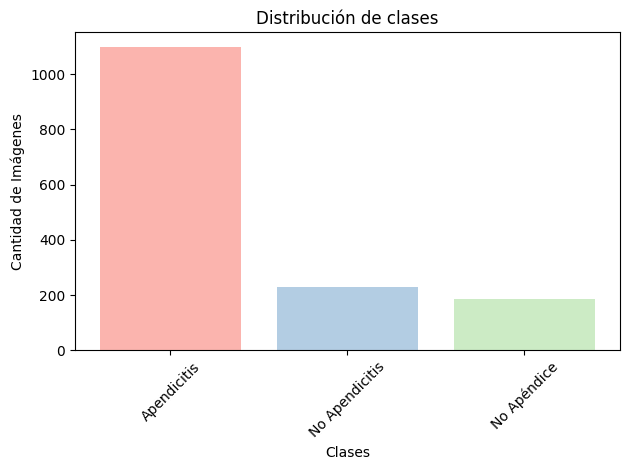


    Apendicitis: 1097, 
    No Apendicitis: 231,
    No Apéndice: 186

Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código


In [27]:
# ia_data_4.py

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Definir la ruta base del proyecto
base_path = Path.cwd().parent

# Rutas de las carpetas de clasificación usando rutas relativas
apendicitis_path = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'apendicitis'
no_apendicitis_path = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'no_apendicitis'
no_apendice_path = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'no_apendice'

# Conteo de archivos en cada categoría
count = {
    'Apendicitis': len(os.listdir(apendicitis_path)), 
    'No Apendicitis': len(os.listdir(no_apendicitis_path)),
    'No Apéndice': len(os.listdir(no_apendice_path))
}

# Crear un DataFrame a partir del diccionario
df = pd.DataFrame(list(count.items()), columns=['Clase', 'Cantidad'])

# Colores pastel
colors = plt.cm.Pastel1.colors

# Crear un gráfico de barras
plt.bar(df['Clase'], df['Cantidad'], color = colors)
plt.xlabel('Clases')
plt.ylabel('Cantidad de Imágenes')
plt.title('Distribución de clases')
plt.xticks(rotation=45)  # Rotar las etiquetas si son demasiado largas
plt.tight_layout()  # Ajustar automáticamente los parámetros de la subtrama
plt.show()

# Información para balancear
print(f'''
    Apendicitis: {len(os.listdir(apendicitis_path))}, 
    No Apendicitis: {len(os.listdir(no_apendicitis_path))},
    No Apéndice: {len(os.listdir(no_apendice_path))}
''')

print('Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código')

El dataset está desbalanceado, por ende se opta por eliminar aleatoriamente instancias de la clase mayoritaria (Undersampling)

In [28]:
# ia_data_5.py

import os
import random
from pathlib import Path

# Definir la ruta base del proyecto
base_path = Path.cwd().parent

# Ruta a la carpeta donde están tus imágenes de la clase 'apendicitis'
apendicitis_path = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'apendicitis'

# Número deseado de muestras después del submuestreo
desired_samples = 250

# Listar todos los archivos de imagen en la carpeta
all_files = [f for f in os.listdir(apendicitis_path) if os.path.isfile(apendicitis_path / f)]

# Seleccionar un subconjunto aleatorio de archivos
selected_files = random.sample(all_files, min(desired_samples, len(all_files)))

# Eliminar los archivos que no han sido seleccionados
for file_name in all_files:
    if file_name not in selected_files:
        os.remove(apendicitis_path / file_name)

# Imprimir la cantidad de imágenes restantes en la carpeta
print(f'La cantidad de imágenes en la carpeta "apendicitis" es: {len(os.listdir(apendicitis_path))}')
print()
print('Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código')

La cantidad de imágenes en la carpeta "apendicitis" es: 250

Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código


Se repite el histograma para asegurar que se hayan balanceado las imágenes

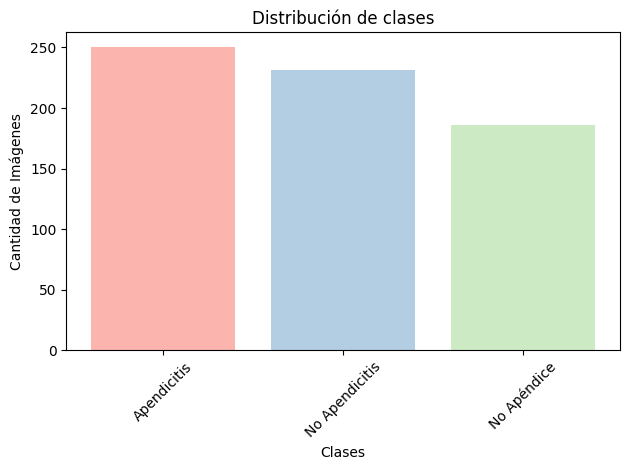


    Apendicitis: 250, 
    No Apendicitis: 231,
    No Apéndice: 186

Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código


In [29]:
# ia_data_4.py

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Definir la ruta base del proyecto
base_path = Path.cwd().parent

# Rutas de las carpetas de clasificación usando rutas relativas
apendicitis_path = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'apendicitis'
no_apendicitis_path = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'no_apendicitis'
no_apendice_path = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas' / 'no_apendice'

# Conteo de archivos en cada categoría
count = {
    'Apendicitis': len(os.listdir(apendicitis_path)), 
    'No Apendicitis': len(os.listdir(no_apendicitis_path)),
    'No Apéndice': len(os.listdir(no_apendice_path))
}

# Crear un DataFrame a partir del diccionario
df = pd.DataFrame(list(count.items()), columns=['Clase', 'Cantidad'])

# Colores pastel
colors = plt.cm.Pastel1.colors

# Crear un gráfico de barras
plt.bar(df['Clase'], df['Cantidad'], color = colors)
plt.xlabel('Clases')
plt.ylabel('Cantidad de Imágenes')
plt.title('Distribución de clases')
plt.xticks(rotation=45)  # Rotar las etiquetas si son demasiado largas
plt.tight_layout()  # Ajustar automáticamente los parámetros de la subtrama
plt.show()

# Información para balancear
print(f'''
    Apendicitis: {len(os.listdir(apendicitis_path))}, 
    No Apendicitis: {len(os.listdir(no_apendicitis_path))},
    No Apéndice: {len(os.listdir(no_apendice_path))}
''')

print('Todo se ha ejecutado exitosamente, puede pasar a la siguiente celda de código')

Es evidente que sigue habiendo un desbalanceo en los datos, pero es algo con lo que se puede trabajar. 

## Aumento de datos

Para evitar que el modelo se aprenda las imágenes en el entrenamiento, generamos varios cambios como rotaciones, zoom, entre otros. 
Este proceso ayudará a que el modelo pueda reconocer las imagenes sin importar su rotación, algo importante puesto que el dataset no fue organizado debidamente y las impagenes no están marcadas como ecografías longitudinales o transversales.

Found 534 images belonging to 4 classes.


Found 133 images belonging to 4 classes.


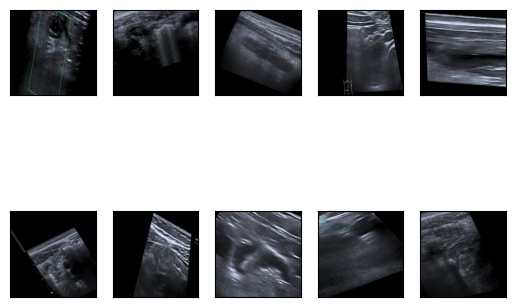

El notebook se ha ejecutado correctamente, espero lo haya disfrutado


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Definir la ruta base del proyecto
base_path = Path.cwd().parent

# Ubicación de las imágenes ordenadas (usando pathlib para construir la ruta)
database = base_path / 'data' / 'us_images' / 'procesadas' / 'ordenadas'

# Instanciar ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=15,
    zoom_range=[0.5, 1.5],
    validation_split=0.2
)

# Generadores para sets de entrenamiento y validación
data_gen_entrenamiento = datagen.flow_from_directory(
    database,
    target_size=(300, 300),
    batch_size=32,
    shuffle=True,
    subset='training'
)

data_gen_pruebas = datagen.flow_from_directory(
    database,
    target_size=(300, 300),
    batch_size=32,
    shuffle=True,
    subset='validation'
)

# Imprimir 10 imágenes del generador de entrenamiento
for imagen, etiqueta in data_gen_entrenamiento:
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(imagen[i])
    break
plt.show()

print('El notebook se ha ejecutado correctamente, espero lo haya disfrutado')

Finalmente nuestro set de entrenamiento y prueba está listo!